In [1]:
import sys
sys.path.append("..")
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.svi as svi
importlib.reload(svi)

smiles = pd.read_csv("../data/spy_smiles_2026-10-06.csv", parse_dates=["expiry"])
svi_params = svi.fit_svi_surface(smiles)

pd.set_option("display.width", 200)
print(svi_params.round(4).to_string())

       expiry       T       a       b     rho       m   sigma  rmse_vol_pts  n_points
0  2026-10-13  0.0192  0.0000  0.0120 -0.7833 -0.0307  0.0259        0.9991        97
1  2026-10-14  0.0219  0.0000  0.0141 -0.9232 -0.0439  0.0395        0.6122        98
2  2026-10-15  0.0247  0.0000  0.0148 -0.8115 -0.0353  0.0343        0.7282        89
3  2026-10-16  0.0274  0.0000  0.0190 -0.9157 -0.0574  0.0465        1.1519       139
4  2026-10-23  0.0466  0.0000  0.0261 -0.9913 -0.0901  0.0740        1.2896       152
5  2026-10-30  0.0658  0.0000  0.0307 -0.9796 -0.0923  0.0890        1.0407       239
6  2026-11-06  0.0849  0.0000  0.0334 -0.9110 -0.0773  0.0861        0.8404       155
7  2026-11-13  0.1041  0.0000  0.0359 -0.8688 -0.0671  0.0869        0.7132       144
8  2026-11-20  0.1233  0.0000  0.0454 -0.9912 -0.1336  0.1361        1.2432       197
9  2026-11-30  0.1507  0.0000  0.0431 -0.9036 -0.0798  0.1101        0.5981       276
10 2026-12-18  0.2000  0.0000  0.0622 -0.9828 -0.1754 

C:\Users\rious\AppData\Local\Temp\ipykernel_5388\449088593.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(svi_params.round(4).to_string())


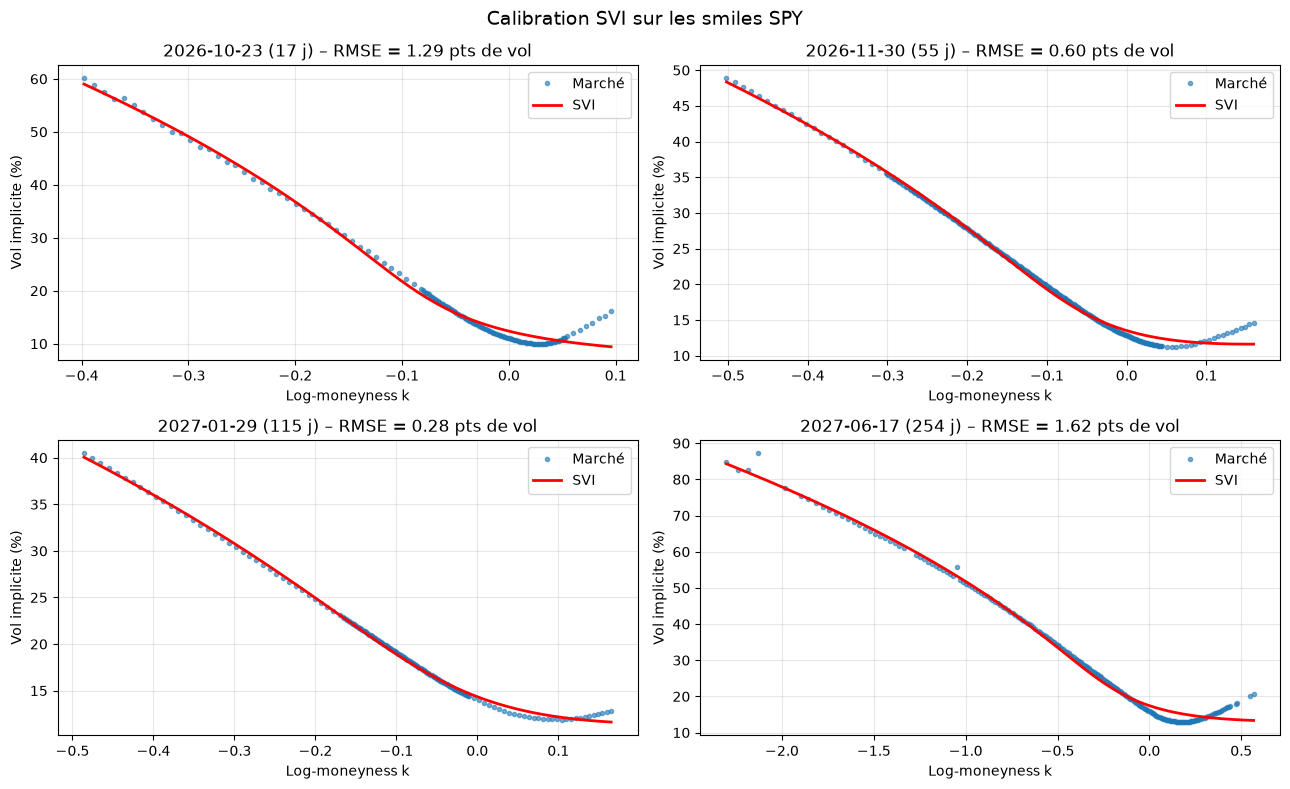

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, days in zip(axes.flat, [17, 55, 115, 254]):
    row = svi_params.iloc[(svi_params["T"] - days / 365).abs().argmin()]
    s = smiles[smiles["expiry"] == row["expiry"]]
    params = row[["a", "b", "rho", "m", "sigma"]].values.astype(float)
    k_fine = np.linspace(s["k"].min(), s["k"].max(), 300)

    ax.plot(s["k"], s["iv"] * 100, "o", ms=3, alpha=0.6, label="Marché")
    ax.plot(k_fine, svi.svi_implied_vol(k_fine, row["T"], params) * 100, "r-", lw=2, label="SVI")
    ax.set_title(f"{row['expiry'].date()} ({row['T'] * 365:.0f} j) – RMSE = {row['rmse_vol_pts']:.2f} pts de vol")
    ax.set_xlabel("Log-moneyness k")
    ax.set_ylabel("Vol implicite (%)")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Calibration SVI sur les smiles SPY", fontsize=14)
fig.tight_layout()
fig.savefig("../figures/svi_fit.png", dpi=150, bbox_inches="tight")
plt.show()